In [1]:
import pandas as pd

In [3]:
data=pd.read_csv("score.csv")
data.head()

,Hours,Scores
0,2.5,21
1,5.1,47
2,3.2,27
3,8.5,75
4,3.5,30


In [4]:
x=data.iloc[:,:-1]
x.head()

,Hours
0,2.5
1,5.1
2,3.2
3,8.5
4,3.5


In [5]:
y=data["Scores"]
y

0     21
1     47
2     27
3     75
4     30
5     20
6     88
7     60
8     81
9     25
10    85
11    62
12    41
13    42
14    17
15    95
16    30
17    24
18    67
19    69
20    30
21    54
22    35
23    76
24    86
Name: Scores, dtype: int64

In [26]:
import matplotlib.pyplot as plt

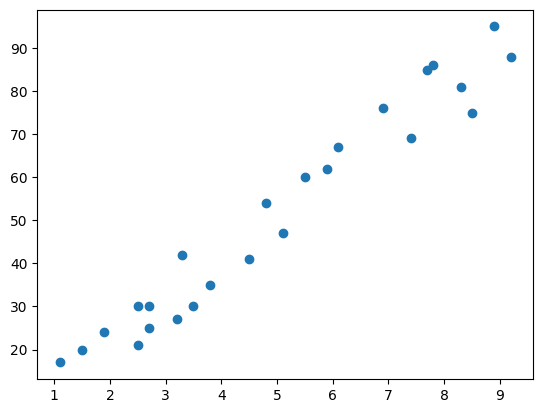

In [27]:
plt.scatter(x,y)
plt.show()

In [28]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25 entries, 0 to 24
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Hours   25 non-null     float64
 1   Scores  25 non-null     int64  
dtypes: float64(1), int64(1)
memory usage: 532.0 bytes


In [30]:
data.describe()

,Hours,Scores
count,25.000000,25.000000
mean,5.012000,51.480000
std,2.525094,25.286887
min,1.100000,17.000000
25%,2.700000,30.000000
50%,4.800000,47.000000
75%,7.400000,75.000000
max,9.200000,95.000000


In [29]:
data.corr() *100

,Hours,Scores
Hours,100.000000,97.619066
Scores,97.619066,100.000000


In [49]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test= train_test_split(x,y, test_size=0.2, random_state = 42)
x_train.shape

(20, 1)

In [50]:
y_train.shape

(20,)

In [51]:
x_test.shape

(5, 1)

In [53]:
y_test.shape

(5,)

In [54]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(x_train, y_train)

LinearRegression()

In [55]:
from sklearn.metrics import r2_score
model.predict([[1.2]])

C:\Users\HP\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([14.44538614])

In [56]:
y_pred=model.predict(x_test)

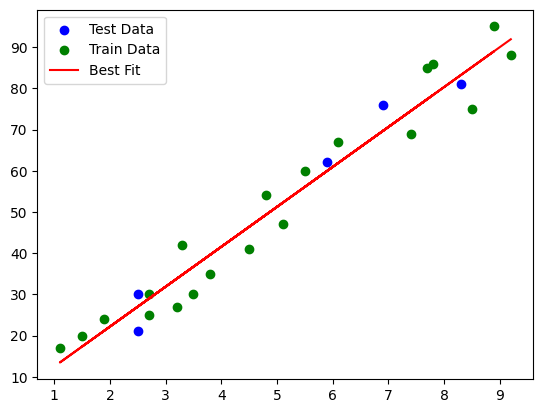

In [57]:
plt.scatter(x_test, y_test, color="blue", label="Test Data")
plt.scatter(x_train, y_train, color="green", label="Train Data")
plt.plot(x_train, model.predict(x_train), color="red", label="Best Fit")
plt.legend()
plt.show()

In [58]:
evaluation = pd.DataFrame({"Actual Value" : y_test,
"Predicted Value" : y_pred,
"Bias/ Error" : y_test - y_pred})
evaluation

,Actual Value,Predicted Value,Bias/ Error
8,81,83.188141,-2.188141
16,30,27.032088,2.967912
0,21,27.032088,-6.032088
23,76,69.633232,6.366768
11,62,59.951153,2.048847


In [59]:
pip install joblib

Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 24.0 -> 24.3.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [60]:
import joblib

In [61]:
joblib.dump(model,"score_predictor.joblib")

['score_predictor.joblib']